# Digit Recognizer

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load the data

In [2]:
dataset_train = pd.read_csv('train.csv')
X_test = pd.read_csv('test.csv')

### Data Exploration

In [3]:
X_train = dataset_train.iloc[:, 1:].values
y_train = dataset_train.iloc[:, 0].values
print(X_train[:25])

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [4]:
y_train = dataset_train.iloc[:, 0].values
y_train[:100]

array([1, 0, 1, 4, 0, 0, 7, 3, 5, 3, 8, 9, 1, 3, 3, 1, 2, 0, 7, 5, 8, 6,
       2, 0, 2, 3, 6, 9, 9, 7, 8, 9, 4, 9, 2, 1, 3, 1, 1, 4, 9, 1, 4, 4,
       2, 6, 3, 7, 7, 4, 7, 5, 1, 9, 0, 2, 2, 3, 9, 1, 1, 1, 5, 0, 6, 3,
       4, 8, 1, 0, 3, 9, 6, 2, 6, 4, 7, 1, 4, 1, 5, 4, 8, 9, 2, 9, 9, 8,
       9, 6, 3, 6, 4, 6, 2, 9, 1, 2, 0, 5])

# Using CNN

In [5]:
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.values.reshape(X_test.shape[0], 28, 28,1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

In [6]:
from keras.utils import to_categorical
y_train = to_categorical(y_train, num_classes=10)

## Build the model

In [7]:
# Simple CNN model
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)


Epoch 1/10


/Users/aaravgoyal/Library/Python/3.12/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9049 - loss: 0.3462 - val_accuracy: 0.9533 - val_loss: 0.1559
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9662 - loss: 0.1181 - val_accuracy: 0.9631 - val_loss: 0.1066
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9765 - loss: 0.0805 - val_accuracy: 0.9721 - val_loss: 0.0832
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9803 - loss: 0.0645 - val_accuracy: 0.9781 - val_loss: 0.0663
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9843 - loss: 0.0521 - val_accuracy: 0.9786 - val_loss: 0.0674
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9858 - loss: 0.0451 - val_accuracy: 0.9802 - val_loss: 0.0635
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9881 - loss: 0.0384 - val_accuracy: 0.9793 - val_loss: 0.0672
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9893 - loss: 0.0344 - val_accuracy: 0.9810 - val_

In [8]:
# Evaluate the model
loss, accuracy = model.evaluate(X_train, y_train)
print(f'Training Accuracy: {accuracy*100:.2f}%')

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 605us/step - accuracy: 0.9932 - loss: 0.0236
Training Accuracy: 99.32%


## Make Predictions

In [9]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 568us/step


## Prepare Submission

In [10]:
submission = pd.DataFrame({
    'ImageId': np.arange(1, len(predicted_classes) + 1),
    'Label': predicted_classes
})
submission.to_csv('submission.csv', index=False)

## Visualize some predictions

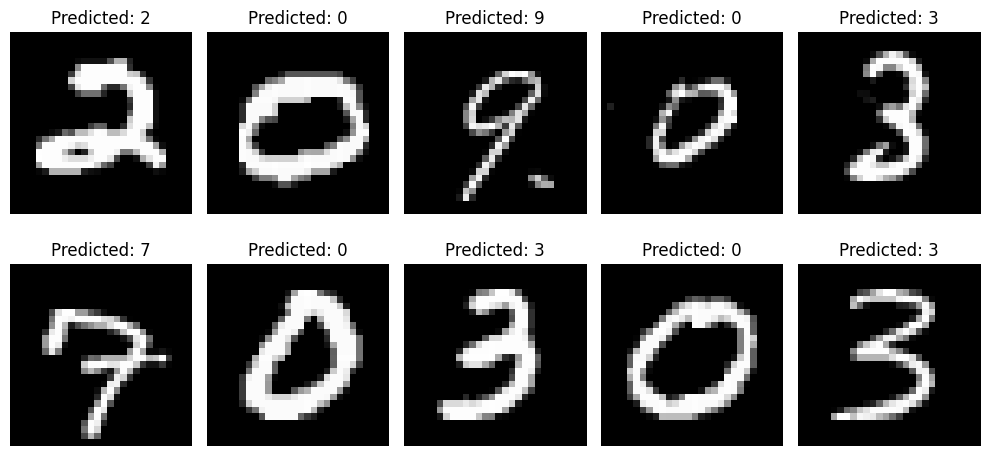

In [11]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f'Predicted: {predicted_classes[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()